In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
import pandas as pd

df = pd.read_csv('titanic_data_updated.csv')

print(f"Dataset Shape--> \n{df.shape}")
print("-" * 50)

print(f"\nFirst 10 Rows-->")
display(df.head(10))
print("-" * 50)

print(f"\n5 Random Samples-->")
display(df.sample(5))

Dataset Shape--> 
(891, 12)
--------------------------------------------------

First 10 Rows-->


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,no,third,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,no,first,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,no,third,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,yes,third,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,yes,second,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


--------------------------------------------------

5 Random Samples-->


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
640,641,no,third,"Jensen, Mr. Hans Peder",male,20.0,0,0,350050,7.8542,NaN,S
17,18,yes,second,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
721,722,no,third,"Jensen, Mr. Svend Lauritz",male,17.0,1,0,350048,7.0542,NaN,S
382,383,no,third,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S
380,381,yes,first,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C


In [4]:
from sklearn.model_selection import train_test_split

df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train--> {X_train.shape}")
print(f"Shape of X_test--> {X_test.shape}\n")

print(f"Shape of y_train--> {y_train.shape}")
print(f"Shape of y_test--> {y_test.shape}")


Shape of X_train--> (712, 8)
Shape of X_test--> (179, 8)

Shape of y_train--> (712,)
Shape of y_test--> (179,)


In [5]:
import numpy as np
from sklearn.impute import SimpleImputer



age_imputer = SimpleImputer(missing_values=np.nan,
                            strategy='mean')
age_imputer.fit(X_train[['Age']])
X_train['Age'] = age_imputer.transform(X_train[['Age']]).ravel()
X_test['Age'] = age_imputer.transform(X_test[['Age']]).ravel()



embar_imputer = SimpleImputer(missing_values=np.nan,
                              strategy='most_frequent')
embar_imputer.fit(X_train[['Embarked']])
X_train['Embarked'] = embar_imputer.transform(X_train[['Embarked']]).ravel()
X_test['Embarked'] = embar_imputer.transform(X_test[['Embarked']]).ravel()



cabin_imputer = SimpleImputer(missing_values=np.nan,
                               strategy='constant',
                               fill_value='Missing')
cabin_imputer.fit(X_train[['Cabin']])
X_train['Cabin'] = cabin_imputer.transform(X_train[['Cabin']]).ravel()
X_test['Cabin'] = cabin_imputer.transform(X_test[['Cabin']]).ravel()

print(f"Checking X_train Missing Values-->")
display(X_train.isnull().sum())
print("-" * 40)

print(f"\nChecking X_test Missing Values-->")
display(X_test.isnull().sum())

Checking X_train Missing Values-->


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64

----------------------------------------

Checking X_test Missing Values-->


Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Cabin       0
Embarked    0
dtype: int64

# Scaling

### Standard Scaling

In [7]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()

ss.fit(X_train[['Age']])
X_train['Age'] = ss.transform(X_train[['Age']]).ravel()
X_test['Age'] = ss.transform(X_test[['Age']]).ravel()

In [10]:
round(X_train['Age'].mean())

0

In [11]:
round(X_train['Age'].std())

1

### Min Max Scaling

<Axes: xlabel='Fare', ylabel='Density'>

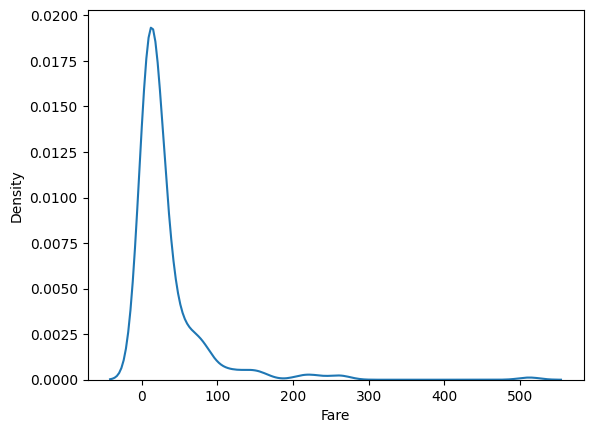

In [13]:
sns.kdeplot(data=X_train, x='Fare')

In [26]:
from sklearn.preprocessing import MinMaxScaler

mnms = MinMaxScaler()
mnms.fit(X_train[['Fare']])
X_train['Fare'] = mnms.transform(X_train[['Fare']]).ravel()
X_test['Fare'] = mnms.transform(X_test[['Fare']]).ravel()

In [16]:
X_train.describe()

,Age,SibSp,Parch,Fare
count,7.120000e+02,712.000000,712.000000,712.000000
mean,1.509404e-16,0.553371,0.379213,0.063604
std,1.000703e+00,1.176404,0.791669,0.101438
min,-2.239388e+00,0.000000,0.000000,0.000000
25%,-5.774929e-01,0.000000,0.000000,0.015469
50%,2.735977e-16,0.000000,0.000000,0.028213
75%,4.236488e-01,1.000000,0.000000,0.059532
max,3.889139e+00,8.000000,6.000000,1.000000


### Robust Scaler

In [23]:
df = pd.read_csv('marks_dataset.csv')

<Axes: xlabel='maths_marks', ylabel='Density'>

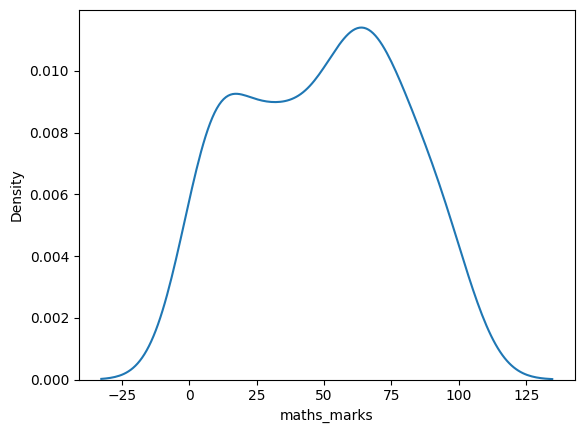

In [22]:
sns.kdeplot(data=df, x='maths_marks')

In [25]:
df.describe()

,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,48.950000,56.010000,52.48000,51.510000,46.180000
std,28.999956,26.487846,27.02542,29.081041,23.590522
min,2.000000,4.000000,1.00000,2.000000,3.000000
25%,27.000000,39.500000,32.00000,29.250000,27.000000
50%,52.500000,59.000000,51.00000,52.500000,42.500000
75%,70.250000,76.000000,76.00000,77.000000,65.000000
max,100.000000,99.000000,97.00000,100.000000,98.000000


In [27]:
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()
rs.fit(df[['maths_marks']])
df['maths_marks'] = rs.transform(df[['maths_marks']])

<Axes: xlabel='maths_marks', ylabel='Density'>

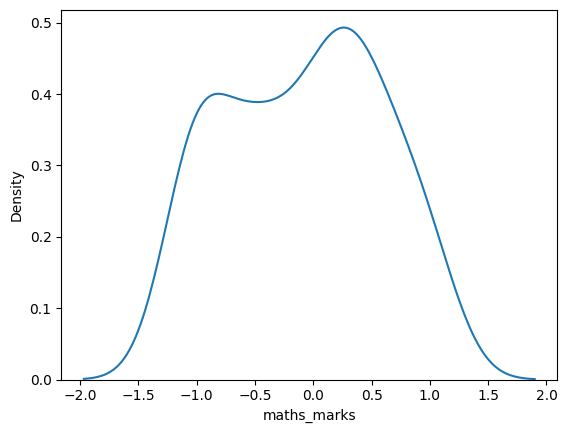

In [29]:
sns.kdeplot(data=df, x='maths_marks')

In [28]:
df.describe()

,maths_marks,science_marks,english_marks,social_studies_marks,language_marks
count,100.000000,100.000000,100.00000,100.000000,100.000000
mean,-0.082081,56.010000,52.48000,51.510000,46.180000
std,0.670519,26.487846,27.02542,29.081041,23.590522
min,-1.167630,4.000000,1.00000,2.000000,3.000000
25%,-0.589595,39.500000,32.00000,29.250000,27.000000
50%,0.000000,59.000000,51.00000,52.500000,42.500000
75%,0.410405,76.000000,76.00000,77.000000,65.000000
max,1.098266,99.000000,97.00000,100.000000,98.000000
